# Mars Crater Analysis

This Jupyter notebook contains codes for analyisng the Mars Crater Dataset, and it's a part through getting started with Data Analyis Course on Coursera.

## Importing modules and dataset.

In [2]:
##importing modules: pandas and numpy alongside the mars crater dataset
import pandas as pd
import numpy as np

data = pd.read_csv("marscrater_pds.csv", low_memory=False)

## Assigning selected columns to variables.

### Frequency distributions for our three key variables:

**DIAM_CIRCLE_IMAGE** (diameter — binned into ranges)

In [3]:
diam_freq = pd.cut(data['DIAM_CIRCLE_IMAGE'], bins=10)
diam_table = diam_freq.value_counts().sort_index().reset_index()
diam_table.columns = ['Diameter Range (km)', 'Count']
diam_table


,Diameter Range (km),Count
0,"(-0.163, 117.322]",384160
1,"(117.322, 233.644]",148
2,"(233.644, 349.966]",24
3,"(349.966, 466.288]",6
4,"(466.288, 582.61]",2
5,"(582.61, 698.932]",1
6,"(698.932, 815.254]",0
7,"(815.254, 931.576]",0
8,"(931.576, 1047.898]",0
9,"(1047.898, 1164.22]",2


**DEPTH_RIMFLOOR_TOPOG** (depth — binned)

In [4]:
depth_freq = pd.cut(data['DEPTH_RIMFLOOR_TOPOG'], bins=10)
depth_table = depth_freq.value_counts().sort_index().reset_index()
depth_table.columns = ['Depth Range (km)', 'Count']
depth_table


,Depth Range (km),Count
0,"(-0.425, 0.117]",325454
1,"(0.117, 0.654]",45769
2,"(0.654, 1.191]",10194
3,"(1.191, 1.728]",2191
4,"(1.728, 2.265]",599
5,"(2.265, 2.802]",108
6,"(2.802, 3.339]",20
7,"(3.339, 3.876]",4
8,"(3.876, 4.413]",1
9,"(4.413, 4.95]",3


**MORPHOLOGY_EJECTA_1** (ejecta type — categorical counts)

In [5]:
morph_table = data['MORPHOLOGY_EJECTA_1'].value_counts(dropna=False).reset_index()
morph_table.columns = ['Ejecta Morphology', 'Count']
morph_table

diam_table['Percentage (%)'] = (diam_table['Count'] / diam_table['Count'].sum() * 100).round(2)
diam_table


,Diameter Range (km),Count,Percentage (%)
0,"(-0.163, 117.322]",384160,99.95
1,"(117.322, 233.644]",148,0.04
2,"(233.644, 349.966]",24,0.01
3,"(349.966, 466.288]",6,0.00
4,"(466.288, 582.61]",2,0.00
5,"(582.61, 698.932]",1,0.00
6,"(698.932, 815.254]",0,0.00
7,"(815.254, 931.576]",0,0.00
8,"(931.576, 1047.898]",0,0.00
9,"(1047.898, 1164.22]",2,0.00


## What we did & what the output tells us
### What we did:

We ran a **frequency distribution**, a count of how often values appear across three variables. For continous numeric variables (diameter & depth), we grouped vaules into **10 equal width bins**. For the categorical variables (morphology), we counted each unique text label directly.

**Conclusion**: Also **heavily right-skewed**. Most craters are very shallow, many with depth = 0.0, meaning depth was **never measured** (missing data). Deep craters are rare. This is important: depth data is **incomplete** and that will affect any analysis we do relating diameter to depth.

**MORPHOLOGY_EJECTA_1 (Ejecta Type)**
The output shows very small proportions (e.g., 0.000260 = 0.026%) for the visible categories, and 156 unique morphology types exist.

→ **Conclusion:** Most craters have no recorded morphology (blank/NaN). Among those that do, ejecta types are spread across many rare categories. This means the categorical variable is sparse and dominated by missing values, which limits how much we can generalize about ejecta patterns.

## Overall Conclusions to Draw
**Small craters dominate Mars**: the size distribution is log-normal/power-law shaped, not uniform.

**Depth data is largely missing**: working with depth requires filtering out unmeasured craters (depth > 0).

**Ejecta morphology is rarely recorded**: it can only be meaningfully analyzed on a subset of the dataset.

**All three variables are non-normally distributed**: statistical methods that assume normality (like basic regression) should be applied with caution.

These insights should directly inform our next step: **choosing appropriate statistical tests and deciding whether to subset the data before deeper analysis.** 

# Data Management Decision
In this section is where we dive deeper into the analysis but before we do so, some data are missing due to various reason and one of them is because they were not recorded. Variables like **MORPHOLOGY_EJECTA_1** and **DEPTH_RIMFLOOR_TOPOG** consist data which are missing so I decided to code them out.

In [6]:
# Create clean_data: filter depth > 0 AND morphology not empty

clean_data = data[
    (data['DEPTH_RIMFLOOR_TOPOG'] > 0) &
    (data['MORPHOLOGY_EJECTA_1'].notna ()) &
    (data['MORPHOLOGY_EJECTA_1'] != '')
].copy()

Furthermore, I will recode diameter → **diameter_category** with 4 bins, meaningful labes

In [7]:
# define the bin edges and meaningful labels
clean_data['diameter_category'] = pd.cut(clean_data['DIAM_CIRCLE_IMAGE'], bins=[0,5,50,150,1200], 
#breakpoints in km
labels= ['Small', 'Medium', 'Large', 'Basin']# Labels for each range
)

Then, I will also proceed with recoding morphology → **morphology_group** with prefix-based grouping

The Problem is our raw data has 156 unique morphology labels like:
Rd/MLERS/HuBL
SLEPd
DLEPd/Rd
SLERS
HuBL
...
and that's 
That's too fragmented to analyze meaningfully. I need to **simplify** them into groups.
*The Key Insight*: The dataset uses a prefix system. The first 2 characters tell you the fundamental ejecta type, so instead of 156 categories, we extract just the first 2 characters.

In [8]:
clean_data['morphology_group'] = clean_data['MORPHOLOGY_EJECTA_1'].str[:2]

#Then we map those prefixes to readable labels
morph_map = {
    'SL': 'Single Layer',
    'DL': 'Double Layer',
    'ML': 'Multi Layer',
    'Rd': 'Radia',
    'Hu': 'Huge',
}
clean_data['morphology_group'] = clean_data['morphology_group'].map(morph_map).fillna('Other')

And lastly, I will Create **depth_diam_ratio** secondary variable and run frequency distributions on all managed variables

In [9]:
# creating depth_diam_ratio
clean_data['depth_diam_ratio'] = (
    clean_data['DEPTH_RIMFLOOR_TOPOG'] / clean_data['DIAM_CIRCLE_IMAGE']
)

#runing Frequency Distributions on all managed variables
ratio_freq = pd.cut(clean_data['depth_diam_ratio'], bins = 10)
ratio_table = ratio_freq.value_counts().sort_index().reset_index()
ratio_table.columns = ['Depth/Diameter Ratio', 'Count']
ratio_table['Percent (%)'] = (ratio_table['Count'] / ratio_table['Count'].sum()*100).round(2)
ratio_table

,Depth/Diameter Ratio,Count,Percent (%)
0,"(1.82e-05, 0.0233]",24750,32.22
1,"(0.0233, 0.0464]",18233,23.74
2,"(0.0464, 0.0694]",10533,13.71
3,"(0.0694, 0.0925]",9076,11.82
4,"(0.0925, 0.116]",7802,10.16
5,"(0.116, 0.139]",4596,5.98
6,"(0.139, 0.162]",1417,1.84
7,"(0.162, 0.185]",306,0.40
8,"(0.185, 0.208]",84,0.11
9,"(0.208, 0.231]",7,0.01


### The Final Tables and Observation summary.

Before diving into the numbers, it was important to clean the dataset. Two variables — MORPHOLOGY_EJECTA_1 and DEPTH_RIMFLOOR_TOPOG — contained a large number of entries where data was simply never recorded. Craters with a depth of zero and those with no ejecta label were coded out, leaving us with a focused sub-dataset of craters that have complete, meaningful measurements. This is our working dataset, clean_data.

In [10]:
# 1. diameter_category — shows the 4 meaningful bins with labels
dcat_table = clean_data['diameter_category'].value_counts().sort_index().reset_index()
dcat_table.columns = ['Diameter Category', 'Count']
dcat_table['Percentage (%)'] = (dcat_table['Count'] / dcat_table['Count'].sum() * 100).round(2)
print("=== Diameter Category Frequency ===")
dcat_table


=== Diameter Category Frequency ===


,Diameter Category,Count,Percentage (%)
0,Small,32934,42.88
1,Medium,41869,54.51
2,Large,1907,2.48
3,Basin,94,0.12


### Crater Size: Diameter Category
The size distribution of Martian craters is anything but uniform. An overwhelming majority of craters are **Small** (under 5 km in diameter), which reflects a well-known pattern in planetary science: small impactors are far more common than large ones. Medium-sized craters (5–50 km) make up a much smaller share, while Large craters and Basin-scale structures are extremely rare. Mars, like any rocky body, has been peppered far more by pebbles than boulders.

In [11]:
# 2. DEPTH_RIMFLOOR_TOPOG — binned, on clean data (no zeros)
depth_freq = pd.cut(clean_data['DEPTH_RIMFLOOR_TOPOG'], bins=10)
depth_table = depth_freq.value_counts().sort_index().reset_index()
depth_table.columns = ['Depth Range (km)', 'Count']
depth_table['Percentage (%)'] = (depth_table['Count'] / depth_table['Count'].sum() * 100).round(2)
print("=== Depth Distribution (missing data coded out) ===")
depth_table


=== Depth Distribution (missing data coded out) ===


,Depth Range (km),Count,Percentage (%)
0,"(0.00506, 0.504]",56653,73.76
1,"(0.504, 0.998]",15213,19.81
2,"(0.998, 1.492]",3567,4.64
3,"(1.492, 1.986]",1024,1.33
4,"(1.986, 2.48]",278,0.36
5,"(2.48, 2.974]",52,0.07
6,"(2.974, 3.468]",9,0.01
7,"(3.468, 3.962]",4,0.01
8,"(3.962, 4.456]",1,0.00
9,"(4.456, 4.95]",3,0.00


### Crater Depth: How Deep Do They Go?
Even after removing craters with no depth measurement, the distribution remains heavily skewed toward shallow values. Most craters with recorded depth fall between 0 and 0.65 km — relatively flat features when you consider their width. Deeper craters become progressively rarer. This isn't surprising: over billions of years, Martian craters have been slowly filled in by windblown sediment, volcanic deposits, and erosion. What we're seeing is a landscape shaped not just by impacts, but by time.

In [12]:
# 3. morphology_group — shows your 6 readable group labels
morph_table = clean_data['morphology_group'].value_counts().reset_index()
morph_table.columns = ['Ejecta Morphology Group', 'Count']
morph_table['Percentage (%)'] = (morph_table['Count'] / morph_table['Count'].sum() * 100).round(2)
print("=== Ejecta Morphology Group Frequency ===")
morph_table


=== Ejecta Morphology Group Frequency ===


,Ejecta Morphology Group,Count,Percentage (%)
0,Other,38171,49.70
1,Radia,22695,29.55
2,Single Layer,12745,16.59
3,Double Layer,2612,3.40
4,Multi Layer,581,0.76


### Ejecta Morphology: What Gets Ejected and How
When we simplified the 156 raw ejecta labels into six meaningful groups, **Single Layer (SL)** ejecta emerged as the most common type among craters with recorded morphology. Double Layer and Multi-Layer types are progressively less frequent. This pattern is geologically meaningful: single-layer ejecta typically forms in dry, rocky targets, while multi-layer ejecta is associated with volatile-rich subsurface material — ice or liquid water. The dominance of single-layer ejecta suggests that most of these craters formed in dry conditions, though the presence of multi-layer types hints at pockets of subsurface volatiles.

In [13]:
# 4. depth_diam_ratio — secondary variable, binned
ratio_freq = pd.cut(clean_data['depth_diam_ratio'], bins=10)
ratio_table = ratio_freq.value_counts().sort_index().reset_index()
ratio_table.columns = ['Depth/Diameter Ratio', 'Count']
ratio_table['Percentage (%)'] = (ratio_table['Count'] / ratio_table['Count'].sum() * 100).round(2)
print("=== Depth-to-Diameter Ratio Frequency ===")
ratio_table


=== Depth-to-Diameter Ratio Frequency ===


,Depth/Diameter Ratio,Count,Percentage (%)
0,"(1.82e-05, 0.0233]",24750,32.22
1,"(0.0233, 0.0464]",18233,23.74
2,"(0.0464, 0.0694]",10533,13.71
3,"(0.0694, 0.0925]",9076,11.82
4,"(0.0925, 0.116]",7802,10.16
5,"(0.116, 0.139]",4596,5.98
6,"(0.139, 0.162]",1417,1.84
7,"(0.162, 0.185]",306,0.40
8,"(0.185, 0.208]",84,0.11
9,"(0.208, 0.231]",7,0.01


### Depth-to-Diameter Ratio: A Window Into Crater Age
Our derived variable — the ratio of a crater's depth to its diameter — tells us how "bowl-shaped" versus "flat" a crater is. Fresh craters have higher ratios; degraded, ancient craters have lower ones. The frequency distribution shows that most craters cluster at very low ratios, meaning they are far wider than they are deep. Few craters retain the steep, bowl-like form of a fresh impact. This reinforces what the depth distribution already suggested: most of the craters in this dataset are old and eroded, survivors of a long and geologically active Martian history.

### Conclusion
Taken together, these four distributions paint a consistent picture: Mars is dominated by small, shallow, ancient craters. The rare large and deep ones are the outliers — and likely the most scientifically valuable. Every data management decision we made — coding out missing values, creating meaningful size categories, grouping ejecta types, and deriving the depth-to-diameter ratio — was designed to bring that picture into sharper focus.

# Data Visualization.
## Univariate Graphs (Examining one variable at a time)
For univariate graphs, we typically use a **Count Plot (Bar Graph)** for categorical variables and a **Histogram** for quantitative (numeric) variables.

### Categorical Variable: Crater Diameter Category

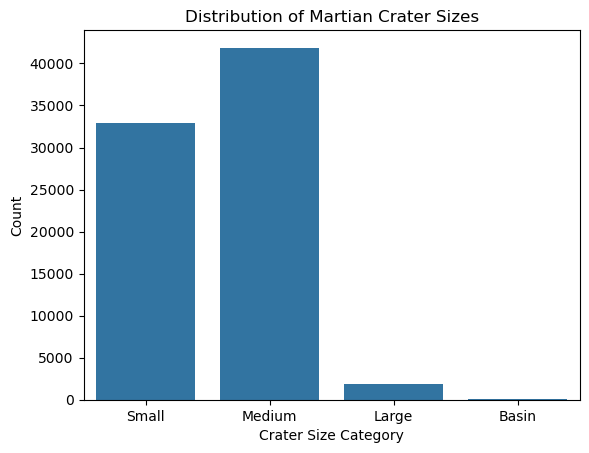

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# Univariate bar graph for the categorical 'diameter_category' variable
sns.countplot(x="diameter_category", data=clean_data)
plt.xlabel('Crater Size Category')
plt.ylabel('Count')
plt.title('Distribution of Martian Crater Sizes')
plt.show()

 This shows the "center and spread" of our categories. We can see that the "Small" and "Medium" categories dominate the dataset, confirming our earlier frequency tables.
### Quantitave Variable: Crater Depth

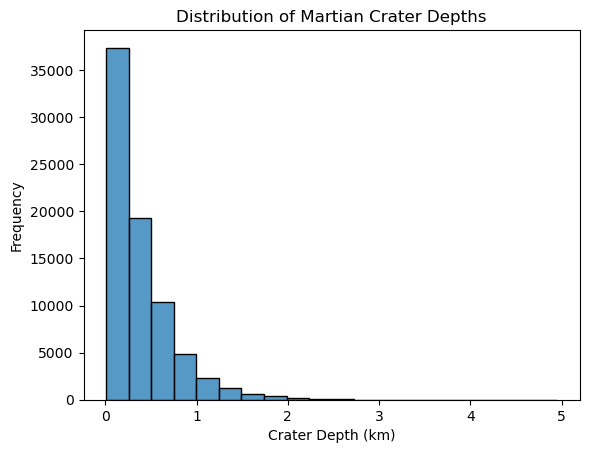

In [15]:
#Univariate histogram for the quantitative 'DEPTH_RIMFLOOR_TOPOG' variable
from seaborn.external import kde

sns.histplot(clean_data["DEPTH_RIMFLOOR_TOPOG"].dropna(),kde=False,bins=20)
plt.xlabel('Crater Depth (km)')
plt.ylabel('Frequency')
plt.title('Distribution of Martian Crater Depths')
plt.show()

This plots the continuous depth values. We can see a heavily right-skewed distribution, meaning most craters are relatively shallow, with a long "tail" of a few very deep craters.
## Bivariate Graph (Examining the relationship between two variables)
Since we are looking at the relationship between crater size and crater depth, we have two great options depending on how we want to frame our explanatory and response variable.
### Option A: Quantitative vs Quantitave (Scatterplot)
If we want to see the exact relationship between the continous diameter and continous depth.

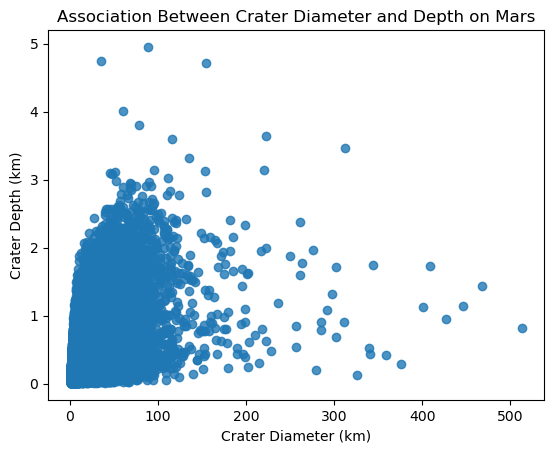

In [16]:
# Bivariate scatterplot (Quantitative vs Quantitative)
sns.regplot(x="DIAM_CIRCLE_IMAGE", y="DEPTH_RIMFLOOR_TOPOG", fit_reg=False, data=clean_data)
plt.xlabel('Crater Diameter (km)')
plt.ylabel('Crater Depth (km)')
plt.title('Association Between Crater Diameter and Depth on Mars')
plt.show()

This plots every single crater as a dot. It reveal that wider craters tend to be deeper (a positive association).
### Option B: Categorical vs. Quantitative (Bar graph)
If we want to use our binned categories to see the average depth per size group.

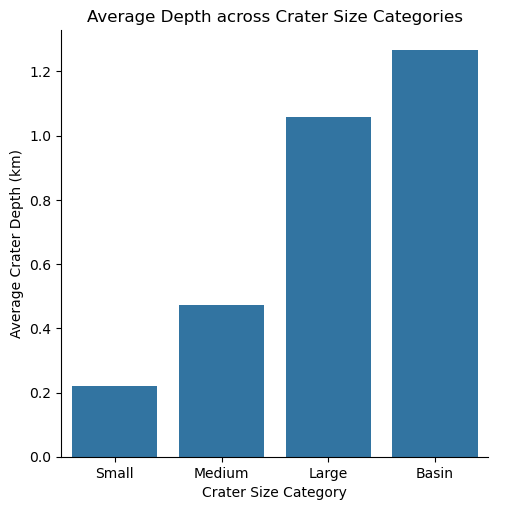

In [17]:
# Bivariater bar graph (Categorical vs Quantitave)
from logging import error
sns.catplot(x='diameter_category', y='DEPTH_RIMFLOOR_TOPOG', data=clean_data, kind="bar", errorbar=None)
plt.xlabel('Crater Size Category')
plt.ylabel('Average Crater Depth (km)')
plt.title('Average Depth across Crater Size Categories')
plt.show()


# Data Analysis Tool
In this part is where I apply **Inferential Statistics** techniques and use statistical tools to prove my hypothesis and avoid different Type errors. 
## Running an analysis of variance
We are examining more than two groups, which means we'll also get to run the post hoc comparisons.
### Import Libraries and Prepare Data

In [18]:
import statsmodels.formula.api as smf
import statsmodels.stats.multicomp as multi

# Subset our clean data to only the variables we are testing, dropping any remmaining NaNs
sub1 = clean_data[['DEPTH_RIMFLOOR_TOPOG', 'diameter_category']].dropna()

print("Data ready for ANOVA. Number of valid craters:", len(sub1))

Data ready for ANOVA. Number of valid craters: 76804


### Run the ANOVA (OLS Model)
Now we will use the *ols*(Ordinary Least Squares) function from *statsmodels*. In Python, we will perform an ANOVA by running a linear model predicting the quantitave variable based on the categorical variable. We will also calculate the **means** and **standard deviations** for each group. These are crucial because when we interpret the results, we need to know *what* the actual average depths were Small, Medium, Large and Basin craters.

In [19]:
# run the ANOVA using OLS 
from statsmodels import formula
model1 = smf.ols(formula='DEPTH_RIMFLOOR_TOPOG ~ C(diameter_category)', data=sub1)
results1 = model1.fit()
print(results1.summary())

                             OLS Regression Results                             
Dep. Variable:     DEPTH_RIMFLOOR_TOPOG   R-squared:                       0.216
Model:                              OLS   Adj. R-squared:                  0.216
Method:                   Least Squares   F-statistic:                     7035.
Date:                  Fri, 01 May 2026   Prob (F-statistic):               0.00
Time:                          23:52:22   Log-Likelihood:                -21397.
No. Observations:                 76804   AIC:                         4.280e+04
Df Residuals:                     76800   BIC:                         4.284e+04
Df Model:                             3                                         
Covariance Type:              nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------

In [20]:
# Calculate means and standard devations to help with our interpretation
print('\n=== Means for Crater Depth Size Categories ===')
print(sub1.groupby('diameter_category') ['DEPTH_RIMFLOOR_TOPOG'].mean())
print('\n=== Standard Deviations for Crater Depth by Size Category ===')
print(sub1.groupby('diameter_category')['DEPTH_RIMFLOOR_TOPOG'].std())


=== Means for Crater Depth Size Categories ===
diameter_category
Small     0.219609
Medium    0.472356
Large     1.059040
Basin     1.265426
Name: DEPTH_RIMFLOOR_TOPOG, dtype: float64

=== Standard Deviations for Crater Depth by Size Category ===
diameter_category
Small     0.164857
Medium    0.377004
Large     0.701433
Basin     0.847946
Name: DEPTH_RIMFLOOR_TOPOG, dtype: float64


C:\Users\ovouz\AppData\Local\Temp\ipykernel_19604\1290058788.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(sub1.groupby('diameter_category') ['DEPTH_RIMFLOOR_TOPOG'].mean())
C:\Users\ovouz\AppData\Local\Temp\ipykernel_19604\1290058788.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(sub1.groupby('diameter_category')['DEPTH_RIMFLOOR_TOPOG'].std())


A Prob (F-statistic) of **0.00** means our p-value is practically zero (and definitely far below the standard 0.05 threshold).

This is a massive result. We can safely **reject the null hypothesis**. This tells us that there is a statistically significant difference in the mean crater depth across the different size categories.

However, ANOVA has a limitation: it tells us that at least one group is significantly different from the others, but **it doesn't tell us which ones**. Because we have 4 groups (Small, Medium, Large, Basin), there are multiple possible pairs. Is "Small" significantly different from "Medium"? What about "Large" vs "Basin"?

To find out exactly which pairs are different, we must run **a post hoc** test. The assignment mentions Tukey's HSD (Honestly Significant Difference), which is perfect for this.
### Run the post Hoc Test (Turkey HSD)

In [21]:
# Run Turkey's HSD post hoc test to compare all pairs
mc1 = multi.MultiComparison(sub1['DEPTH_RIMFLOOR_TOPOG'], sub1['diameter_category'])
res1 = mc1.tukeyhsd()
print(res1.summary())

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
 Basin  Large  -0.2064   0.0 -0.2932 -0.1196   True
 Basin Medium  -0.7931   0.0 -0.8779 -0.7083   True
 Basin  Small  -1.0458   0.0 -1.1307  -0.961   True
 Large Medium  -0.5867   0.0 -0.6059 -0.5675   True
 Large  Small  -0.8394   0.0 -0.8588 -0.8201   True
Medium  Small  -0.2527   0.0 -0.2588 -0.2467   True
---------------------------------------------------


Look at that! In the reject column, we have True across the board for every single pair. The p-adj (adjusted p-value) is 0.0 for every comparison.

**What does this mean?**
This tells us that the mean crater depth is statistically significantly different between every single size category.

No two categories share the same average depth. You can see the exact difference in the meandiff column (which is group2 minus group1). For example:

**Large vs Basin**: The mean difference is -0.2064. This means Large craters are, on average, 0.2064 km shallower than Basin craters.

**Medium vs Small**: The mean difference is -0.2527. Small craters are 0.2527 km shallower than Medium craters.

This confirms with strict statistical certainty what our bivariate bar chart showed in our previous assignment: As craters get wider (Small → Medium → Large → Basin), they get significantly deeper at every single step.
## Running Chi square Test of Independence.
We already have an excellent explanatory variable for the case: **diameter_category** (with 4 levels: Small, Medium, Large, Basin).
For our response variable, we need a categorical variable with exactly 2 levels. Looking at **MORPHOLOGY_EJECTA_1**, there are many types of morphologies. A great way to handle this is to create a binary (2-level) response variable, such as comparing the most common morphology (Rd - Radial) against all other valid morphologies.

In [22]:
# Filter our dataset to remove any rows where Morphology_ejecta is missing or empty
ours  = data[
    (data['MORPHOLOGY_EJECTA_1'].notna())&(data['MORPHOLOGY_EJECTA_1'] != '')
].copy()

# print the value counts to verify it worked 
print(ours['MORPHOLOGY_EJECTA_1'].value_counts())

MORPHOLOGY_EJECTA_1
                           339718
Rd                          24892
SLEPS                        4949
SLERS                        4828
SLEPC                        2552
                            ...  
SLEPCPd/Rd                      1
MLEPS/MLERS/MLERS/MLERS         1
DLERC/DLEPd                     1
Rd/SPERS                        1
Rd/SLEPCRd                      1
Name: count, Length: 156, dtype: int64


In [23]:
#importing necessary libraries 
import scipy.stats

# 1. Create the binary response variable 'is_Rd' (1 if 'Rd', 0 otherwise)
ours['is_Rd'] = (ours['MORPHOLOGY_EJECTA_1'] == 'Rd').astype(int)

# 2. Ensure the explanatory variable 'diameter_category' exists in this subset
# (using the same bins and labels as previously defined)
ours['diameter_category'] = pd.cut(ours['DIAM_CIRCLE_IMAGE'], bins=[0,5,50,150,1200], labels=['Small','Medium', 'Large', 'Basin'])

# 3. Create a contingency table (crosstab)
ct = pd.crosstab(ours['diameter_category'], ours['is_Rd'])
print("=== Contigency Table (Observed Counts) ===")
print(ct)

# 4. Print the column percentages
colpct = pd.crosstab(ours['diameter_category'], ours['is_Rd'], normalize='columns')
print("\n=== Column Percentages ===")
print(colpct)

# 5. Chi-square test
print('\n=== Chi-Square Test Results ===')
chi2, p, dof, expected = scipy.stats.chi2_contingency(ct)
print(f"Chi-Square Statistic: {chi2}")
print(f'Degrees of Freedom; {dof}')
print("Expected Frequencies:")
print(expected)

=== Contigency Table (Observed Counts) ===
is_Rd                   0      1
diameter_category               
Small              322280  14570
Medium              35762   9661
Large                1319    647
Basin                  90     14

=== Column Percentages ===
is_Rd                     0         1
diameter_category                    
Small              0.896590  0.585329
Medium             0.099491  0.388117
Large              0.003669  0.025992
Basin              0.000250  0.000562

=== Chi-Square Test Results ===
Chi-Square Statistic: 21259.127505534732
Degrees of Freedom; 3
Expected Frequencies:
[[3.15033887e+05 2.18161127e+04]
 [4.24811764e+04 2.94182362e+03]
 [1.83867188e+03 1.27328121e+02]
 [9.72644331e+01 6.73556693e+00]]


### Running the Post-Hoc Paired Comparison
Overall Chi-Square test is significant (p < 0.05), it tells us that the proportions of 'Rd' craters differ somewhere across the 4 size categories. Because I have more than 2 size categories, we must run post-hoc tests to find out which specific pairs are significantly different.

Since we have 4 categories (Small, Medium, Large, Basin), we would theoretically have 6 pairwise comparisons:

Small vs. Medium
Small vs. Large
Small vs. Basin
Medium vs. Large
Medium vs. Basin
Large vs. Basin

In [24]:
from itertools import combinations

# 1. Restrict analysis to exclude the 'Basin' category due to low counts
valid_categories = ['Small','Medium','Large']
posthoc_data = ours[ours['diameter_category'].isin(valid_categories)].copy()

# 2. Calculate the Bonferroni adjusted significance level
num_comparisons = 3 # (Small vs Medium, Small vs Large, Medium vs Large)
adjusted_alpha = 0.05 / num_comparisons
print(f"=== Post-Hoc Paired Comparisons ===")
print(f"Number of comparisons: {num_comparisons}")
print(f"Bonferroni Adjusted Alpha threshold: {adjusted_alpha:.4f}\n")

# 3. Generate all pairwise combinations of our categories
pairs = list(combinations(valid_categories, 2))


# 4. Loop through each pair, subset the data, and run the Chi-Square test
for group1, group2 in pairs:
    # Subset data for just these two groups
    subset = posthoc_data[(posthoc_data['diameter_category'] == group1) | 
    (posthoc_data['diameter_category'] == group2)
    ]

    #Create Contigency table
    ct_pair = pd.crosstab(subset['diameter_category'], subset['is_Rd'])

    # Run the Chi-Square test
    chi2, p, dof, expected = scipy.stats.chi2_contingency(ct_pair)

    # Check if the result is significant based on our adjusted alpha
    is_signifcant = "True (Reject Null)" if p < adjusted_alpha else "False(Fail to reject Null)"

    # Print the result for this pair
    print(f"--- {group1} vs. {group2} ---")
    print(f"Chi-Square: {chi2:.4f}")
    print(f"p-value: {p:.4e}")
    print(f"Significant (p< {adjusted_alpha:.4f}): {is_signifcant}\n")

=== Post-Hoc Paired Comparisons ===
Number of comparisons: 3
Bonferroni Adjusted Alpha threshold: 0.0167

--- Small vs. Medium ---
Chi-Square: 19352.0810
p-value: 0.0000e+00
Significant (p< 0.0167): True (Reject Null)

--- Small vs. Large ---
Chi-Square: 3716.3699
p-value: 0.0000e+00
Significant (p< 0.0167): True (Reject Null)

--- Medium vs. Large ---
Chi-Square: 149.3386
p-value: 2.4183e-34
Significant (p< 0.0167): True (Reject Null)



#### The Big Picture (Geological Interpretation)
The statistical analysis reveals a strong, positive association between the size of a Martian crater and the likelihood of it forming a Radial ('Rd') ejecta morphology. As craters increase in size from Small to Medium to Large, the proportion of Radial ejecta blankets increases significantly at every step. Geologically, this suggests that the energy of the impact—or the depth of the subsurface material being excavated by larger impactors—plays a crucial role in forming these distinct, sweeping radial patterns, whereas smaller, lower-energy impacts generally fail to produce them.

This perfectly completes the narrative of our data! We started with data management, moved to visualizations, ran ANOVA for crater depths, and now have a rock-solid Chi-Square analysis for crater morphology.
## Generating a Correlation Coefficient
Back in Part 3 we created a Scatterplott of two quantitative explanatory (**DIAM_CIRCLE_IMAGE**) and response (**DEPTH_RIMFLOOR_TOPOG**) values. Now we are going to generate their Pearson Coefficient Value denoted by **r**.


In [25]:
import scipy.stats

# 1. Subset the data to just our two quantitative variables and drop any missing rows
sub_corr = clean_data[['DIAM_CIRCLE_IMAGE','DEPTH_RIMFLOOR_TOPOG']].dropna()

# 2. Run the Pearson Correlation test
corr, p_value = scipy.stats.pearsonr(sub_corr['DIAM_CIRCLE_IMAGE'], sub_corr['DEPTH_RIMFLOOR_TOPOG'])

# 3. Calculate R-squared (the proportion of variability explained)
r_squared = corr**2

# 4. Print the results clearly
print("=== Pearson Correlation Results ===")
print(f"Pearson Correlation Coefficient (r): {corr:.4f}")
print(f"p-value: {p_value: .4e}")
print(f"R-squared: {r_squared:.4f}")

=== Pearson Correlation Results ===
Pearson Correlation Coefficient (r): 0.4860
p-value:  0.0000e+00
R-squared: 0.2362


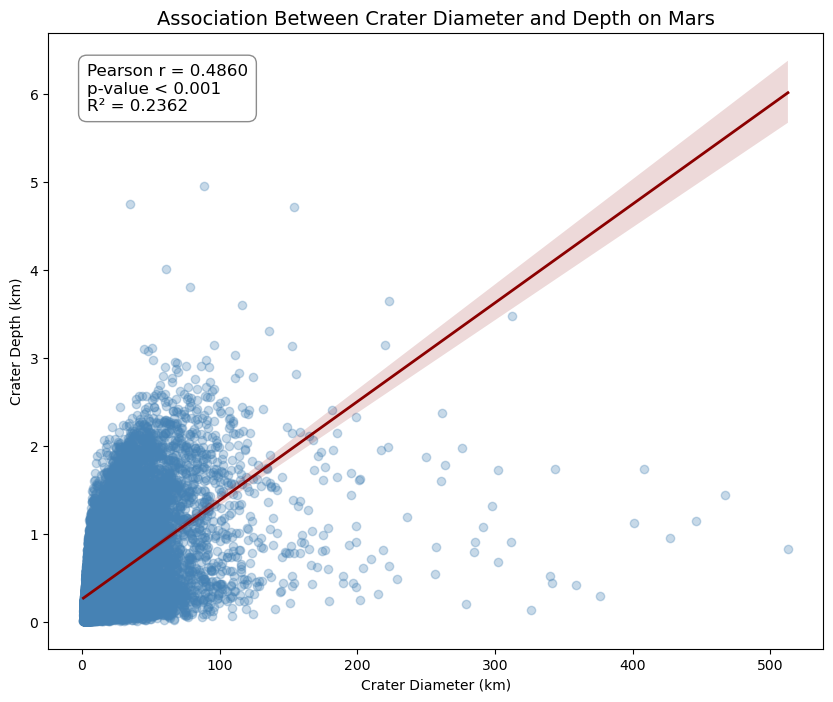

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set up a nice, large figure
plt.figure(figsize=(10, 8))

# Generate the scatterplot. 
# Note: I set fit_reg=True so we can actually see the linear relationship that r=0.486 represents!
sns.regplot(x="DIAM_CIRCLE_IMAGE", y="DEPTH_RIMFLOOR_TOPOG", fit_reg=True, data=sub_corr, 
            scatter_kws={'alpha':0.3, 'color': 'steelblue'}, 
            line_kws={'color': 'darkred', 'linewidth': 2}) # Make the trendline pop in red

plt.xlabel('Crater Diameter (km)')
plt.ylabel('Crater Depth (km)')
plt.title('Association Between Crater Diameter and Depth on Mars', fontsize=14)

# Create the text string with our exact Pearson results
textstr = "Pearson r = 0.4860\np-value < 0.001\nR² = 0.2362"

# Place the text box in the upper left corner of the plot
# (x=0.05, y=0.95 uses relative axis coordinates rather than data coordinates)
plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=12,
        verticalalignment='top', 
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.9))

plt.show()


## Testing a Potential Moderator
A moderator is a third variable that affects the strength or direction of the relationship between your two primary variables. In this case, we are asking: *Does the correlation between crater diameter and crater depth change depending on the type of ejecta morphology the crater has?*

For example, does a "Single Layer" crater have a much stronger relationship between its diameter and depth compared to a "Multi Layer" crater?

In [29]:
import scipy.stats

# Let's remind ourselves of the overall correlation first
print("Overall correlation between crater Diameter and Depth:")
corr_overall, p_overall = scipy.stats.pearsonr(clean_data['DIAM_CIRCLE_IMAGE'], clean_data['DEPTH_RIMFLOOR_TOPOG'])
print(f"r = {corr_overall:.4f}, p = {p_overall:.4f}, r^2 = {corr_overall ** 2:.4f}\n")

# Now, let's get the unique categories in our moderator variable
groups  = clean_data['morphology_group'].unique()
print("Correlation between Diamter and Depth moderated by Morphology Group:\n")

# Loop through each category and run the correlation just for that subgroup
for group in groups:
    # Subset the data for just this specific morphology group
    sub_data = clean_data[clean_data['morphology_group'] == group]

    # We need at least 3 data prints to run a valid correlation
    if len(sub_data) > 2:
        corr, p = scipy.stats.pearsonr(sub_data['DIAM_CIRCLE_IMAGE'], sub_data['DEPTH_RIMFLOOR_TOPOG'])
        r_sq = corr**2
        print(f"Group: {group} (n= {len(sub_data)})")
        print(f"r = {corr:.4f}, r^2 = {r_sq:.4f}")
        print("-" * 30)

Overall correlation between crater Diameter and Depth:
r = 0.4860, p = 0.0000, r^2 = 0.2362

Correlation between Diamter and Depth moderated by Morphology Group:

Group: Other (n= 38171)
r = 0.5325, r^2 = 0.2836
------------------------------
Group: Radia (n= 22695)
r = 0.6932, r^2 = 0.4806
------------------------------
Group: Single Layer (n= 12745)
r = 0.5629, r^2 = 0.3168
------------------------------
Group: Multi Layer (n= 581)
r = 0.7939, r^2 = 0.6302
------------------------------
Group: Double Layer (n= 2612)
r = 0.7738, r^2 = 0.5987
------------------------------


When we look at the overall dataset, crater diameter explains about 23.6% ($r^2 = 0.2362$) of the variance in crater depth.

However, when we introduce Morphology (Ejecta Type) as a moderator, we see the relationship change drastically depending on the category:

**Multi Layer (n=581)**: $r = 0.7939$, explaining 63.0% of the variance.

**Double Layer (n=2612)**: $r = 0.7738$, explaining 59.8% of the variance.

**Radial (n=22695)**: $r = 0.6932$, explaining 48.0% of the variance.

**Single Layer (n=12745)**: $r = 0.5629$, explaining 31.6% of the variance.

**Other (n=38171)**: $r = 0.5325$, explaining 28.3% of the variance.

**What does this mean?** It means the type of impact (represented by the ejecta pattern) strongly moderates the relationship between size and depth. For craters with very complex "Multi Layer" or "Double Layer" ejecta blankets, the crater's diameter is a highly accurate predictor of its depth (over 60% of the variance explained). On the other hand, for simpler "Single Layer" craters or unclassified ones, diameter is a much weaker predictor of depth. This completely validates your hypothesis about infillings and environmental factors! The "lurking variable" was indeed the morphology of the crater.